In [1]:
# 数据预处理
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小

directory = "../datas/test" #设置数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
new_features = ['impedance', 'power', 'cumulative_power', 'impedance_diff', 'impedance_rolling_mean', 'impedance_rolling_std', 'impedance_slope_10']
features = base_features + new_features

for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    #数据预处理 添加阻抗变化率特征
    df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[file] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

print(f'检索到{Sample_size}个样本')
print(f"原始特征数量: {len(base_features)}")
print(f"扩展后特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")
# print(f"生成测试样本数: {len(test_dataset)}")

检索到10个样本
原始特征数量: 2
扩展后特征数量: 9
序列数量: 10


In [2]:
import xgboost as xgb
import torch
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report, confusion_matrix,
                           roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm
import joblib

def create_xgboost_data(sequences_data, sequence_length, prediction_horizon):
    X_list = []
    y_list = []
    
    for seq_data in tqdm(sequences_data, desc="处理序列", unit="seq", ncols=60):
        n_samples = len(seq_data) - sequence_length - prediction_horizon + 1
        
        for i in range(n_samples):
            # 提取特征
            x = seq_data[i:i + sequence_length, :-1].flatten()  # 展平为1D向量
            X_list.append(x)
            
            # 提取标签
            y_window = seq_data[i + sequence_length:i + sequence_length + prediction_horizon, -1]
            y = 1 if np.any(y_window == 1) else 0
            y_list.append(y)
    
    return np.array(X_list), np.array(y_list)

print("生成测试数据...")
X_test, y_true = create_xgboost_data(sequences_data, sequence_length, prediction_horizon)
dtest = xgb.DMatrix(X_test, label=y_true)
print(f"测试集形状: X_test {X_test.shape}, y_true {y_true.shape}")

# 从float64转化为float32
# X_test = X_test.astype(np.float32)

model_name = 'XGBoost'
print("加载XGBoost模型中...")
#加载模型
model_path="Model_XGBoost.pkl"
model_data = joblib.load(model_path)
model = model_data['model']
feature_names = model_data['feature_names']

print(f"模型加载成功!")
print(f"特征维度: {len(feature_names)}")
# print(f"训练设备: {'GPU' if gpu_trained else 'CPU'}")
print(f"类别: { model_data['model_type']}")

生成测试数据...


处理序列: 100%|████████████| 10/10 [00:01<00:00,  5.98seq/s]


测试集形状: X_test (116789, 4500), y_true (116789,)
加载XGBoost模型中...
模型加载成功!
特征维度: 4500
类别: booster


In [3]:
print("开始预测...")
y_prob = model.predict(dtest)

# 寻找最佳阈值
print("计算最佳分类阈值...")
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# 使用Youden's J统计量
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]
print(f"最佳阈值: {optimal_threshold:.4f}")
y_pred = (y_prob >= optimal_threshold).astype(int)
print("分类完成")

开始预测...
计算最佳分类阈值...
最佳阈值: 0.0731
分类完成


In [4]:
#输出评估结果
print("=" * 60)
print(f'{model_name}模型预测结果统计')
print("=" * 60)
print(f"测试文件数量: {len(csv_files)}")
print(f"总样本数: {len(y_true)}")
print(f"正样本比例: {np.mean(y_true):.4f} ({np.sum(y_true)}/{len(y_true)})")
print(f"预测正样本比例: {np.mean(y_pred):.4f} ({np.sum(y_pred)}/{len(y_pred)})")
print(f"在最佳阈值下:")
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc_score = roc_auc_score(y_true, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
auc_pr = auc(recall_curve, precision_curve) 
cm = confusion_matrix(y_true, y_pred)
print(f"最佳阈值: {optimal_threshold:.4f}")
print(f"准确率: {accuracy:.4f}")
print(f"精确率: {precision:.4f}")
print(f"召回率: {recall:.4f}")
print(f"F1分数: {f1:.4f}")
print(f"AUC-ROC: {auc_score:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")
print(f"TN: {cm[0,0]}")
print(f"TP: {cm[1,1]}")
print(f"FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}")

# 分类报告
print("\n详细分类报告:")
print(classification_report(y_true, y_pred, target_names=['正常(0)', '异常(1)']))

# 混淆矩阵

print("\n混淆矩阵:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

# 概率统计
print(f"\n预测概率统计:")
print(f"平均概率: {np.mean(y_prob):.4f}")
print(f"概率标准差: {np.std(y_prob):.4f}")
print(f"最小概率: {np.min(y_prob):.4f}")
print(f"最大概率: {np.max(y_prob):.4f}")
print(f"概率中位数: {np.median(y_prob):.4f}")

print("\n" + "=" * 60)
print(f'{model_name}模型预测完成!')
print("=" * 60)
print("\n")
print(f"{optimal_threshold:.4f}")
print(f"{accuracy:.4f}")
print(f"{precision:.4f}")
print(f"{recall:.4f}")
print(f"{f1:.4f}")
print(f"{auc_score:.4f}")
print(f"{auc_pr:.4f}")
print(f"{cm[0,0]}")
print(f"{cm[1,1]}")
print(f"{cm[0,1]}")
print(f"{cm[1,0]}")

XGBoost模型预测结果统计
测试文件数量: 10
总样本数: 116789
正样本比例: 0.1403 (16383/116789)
预测正样本比例: 0.1713 (20007/116789)
在最佳阈值下:
最佳阈值: 0.0731
准确率: 0.9669
精确率: 0.8129
召回率: 0.9927
F1分数: 0.8938
AUC-ROC: 0.9977
AUC-PR: 0.9871
TN: 96662
TP: 16263
FP: 3744
FN: 120

详细分类报告:
              precision    recall  f1-score   support

       正常(0)       1.00      0.96      0.98    100406
       异常(1)       0.81      0.99      0.89     16383

    accuracy                           0.97    116789
   macro avg       0.91      0.98      0.94    116789
weighted avg       0.97      0.97      0.97    116789


混淆矩阵:
TN: 96662, FP: 3744
FN: 120, TP: 16263

预测概率统计:
平均概率: 0.1476
概率标准差: 0.3418
最小概率: 0.0003
最大概率: 0.9989
概率中位数: 0.0003

XGBoost模型预测完成!


0.0731
0.9669
0.8129
0.9927
0.8938
0.9977
0.9871
96662
16263
3744
120


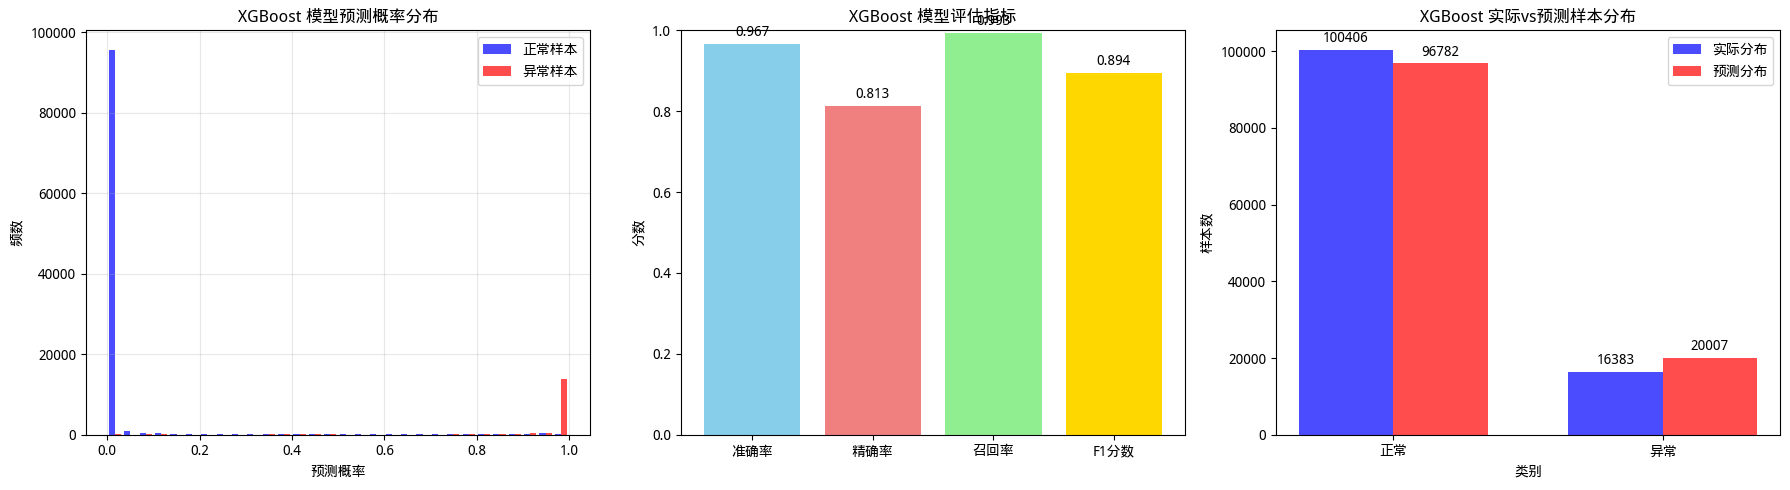

图表已保存至: Test_results_XGBoost/XGBoost_prediction_results_20251217_014133.png


In [5]:
#绘图
import matplotlib

fig1, (ax1, ax3, ax4) = plt.subplots(1, 3, figsize=(18, 5))

# 设置中文字体 for linux
font_path = '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'  # 或者使用 wqy-zenhei.ttc
if os.path.exists(font_path):
    matplotlib.font_manager.fontManager.addfont(font_path)
    font_name = matplotlib.font_manager.FontProperties(fname=font_path).get_name()
else:
    font_name = 'WenQuanYi Micro Hei'
plt.rcParams['font.sans-serif'] = [font_name]  # 设置为默认字体
plt.rcParams['axes.unicode_minus'] = False
# # 设置中文字体
# plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# 1. 概率分布
ax1.hist([np.array(y_prob)[np.array(y_true) == 0], 
          np.array(y_prob)[np.array(y_true) == 1]], 
         bins=30, alpha=0.7, label=['正常样本', '异常样本'], color=['blue', 'red'])
ax1.set_xlabel('预测概率')
ax1.set_ylabel('频数')
ax1.set_title(f'{model_name} 模型预测概率分布')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3. 指标对比
metrics = ['准确率', '精确率', '召回率', 'F1分数']
values = [accuracy, precision, recall, f1]
# values = [results['accuracy'], results['precision'], results['recall'], results['f1']]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
bars = ax3.bar(metrics, values, color=colors)
ax3.set_ylabel('分数')
ax3.set_title(f'{model_name} 模型评估指标')
ax3.set_ylim(0, 1)

# 在柱状图上添加数值
for bar, value in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. 正负样本分布
class_dist = [np.sum(np.array(y_true) == 0), np.sum(np.array(y_true) == 1)]
pred_dist = [np.sum(np.array(y_pred) == 0), np.sum(np.array(y_pred) == 1)]

x = np.arange(2)
width = 0.35

ax4.bar(x - width/2, class_dist, width, label='实际分布', alpha=0.7, color='blue')
ax4.bar(x + width/2, pred_dist, width, label='预测分布', alpha=0.7, color='red')
ax4.set_xlabel('类别')
ax4.set_ylabel('样本数')
ax4.set_title(f'{model_name} 实际vs预测样本分布')
ax4.set_xticks(x)
ax4.set_xticklabels(['正常', '异常'])
ax4.legend()

# 在柱状图上添加数值
for i, (actual, pred) in enumerate(zip(class_dist, pred_dist)):
    ax4.text(i - width/2, actual + max(class_dist)*0.01, f'{actual}', ha='center', va='bottom')
    ax4.text(i + width/2, pred + max(pred_dist)*0.01, f'{pred}', ha='center', va='bottom')

plt.tight_layout()
save_dir = f'Test_results_{model_name}'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = os.path.join(save_dir, f"{model_name}_prediction_results_{timestamp}.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"图表已保存至: {save_path}")

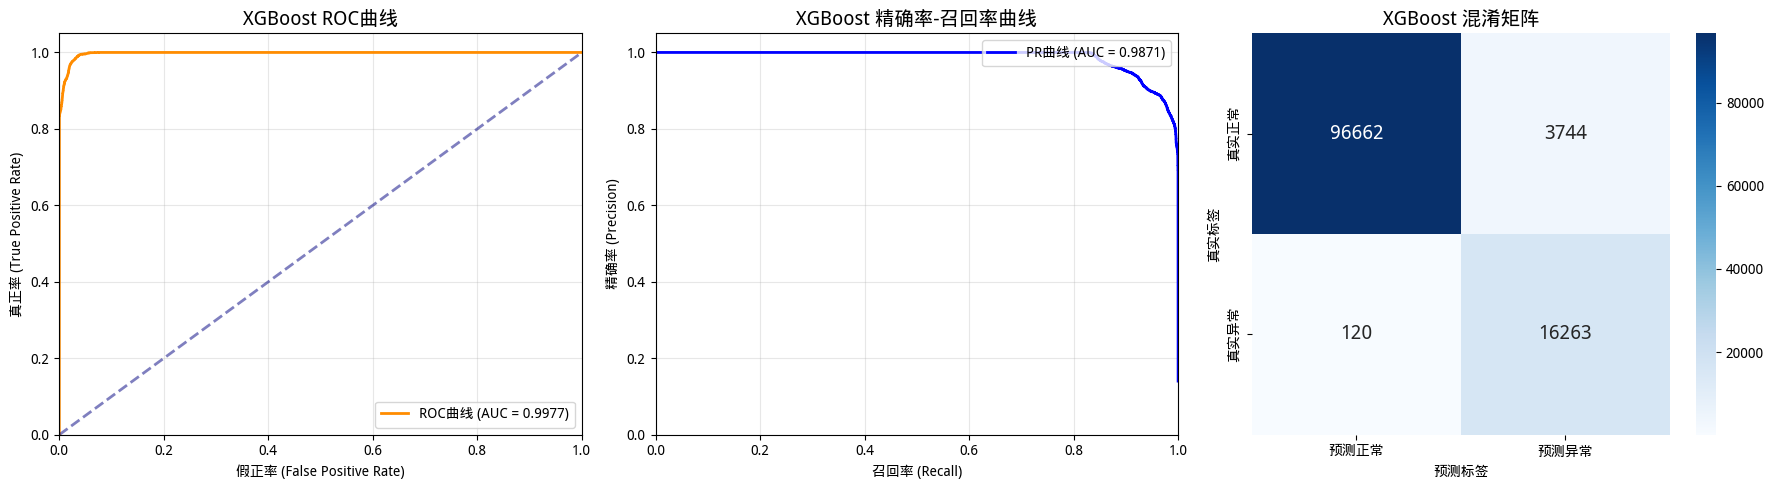

图表已保存至: Test_results_XGBoost/XGBoost_model_evaluation_three_panels20251217_014133.png


In [6]:
# #绘图
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC曲线
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('假正率 (False Positive Rate)')
ax1.set_ylabel('真正率 (True Positive Rate)')
ax1.set_title(f'{model_name} ROC曲线', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# 2. 精确率-召回率曲线
precision2, recall2, _ = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall2, precision2)

ax2.plot(recall2, precision2, color='blue', lw=2, 
         label=f'PR曲线 (AUC = {pr_auc:.4f})')
ax2.set_xlabel('召回率 (Recall)')
ax2.set_ylabel('精确率 (Precision)')
ax2.set_title(f'{model_name} 精确率-召回率曲线', fontsize=14, fontweight='bold')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# 3. 混淆矩阵热力图
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['预测正常', '预测异常'],
            yticklabels=['真实正常', '真实异常'],
            annot_kws={"size": 14})
ax3.set_title(f'{model_name} 混淆矩阵', fontsize=14, fontweight='bold')
ax3.set_xlabel('预测标签')
ax3.set_ylabel('真实标签')

plt.tight_layout()
save_path = os.path.join(save_dir, f"{model_name}_model_evaluation_three_panels{timestamp}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"图表已保存至: {save_path}")